# 07 机器学习：检测 + 分类两级故障识别

**本节目标**

1. 用 `bearing_fault.ml` 子包走通"数据集生成 → 特征工程 → 两级训练 → 评估 → 推理"的
   完整机器学习流程；
2. 理解**两级架构**：检测级（是否异常）与分类级（故障部位）为什么分开；
3. 对比 SVM / 随机森林 / kNN 三个候选分类器的交叉验证成绩，并解读特征重要性。

**两级架构**（文字示意）

```
原始信号 x ──► FeatureExtractor（26 维特征）
                     │
                     ▼
        ┌──────────────────────────────┐
        │ 检测级 EllipticEnvelope       │ ← 只用健康样本的 4 维冲击性特征训练
        │ （稳健马氏距离）               │   判正常 → 直接输出 healthy
        │ kurtosis / crest_factor /     │
        │ clearance_factor / env_max_ratio│
        └──────────────────────────────┘
                     │ 判异常
                     ▼
        ┌──────────────────────────────┐
        │ 分类级 SVM / RF / kNN 择优     │ ← 只用故障样本训练（5 折 CV 选最优）
        └──────────────────────────────┘
                     ▼
        输出 inner / outer / ball / cage + 分类概率
```

**为什么"检测级不需要故障样本"对工业现场很重要**

- 现场长期积累的数据几乎全是健康数据，真实故障样本稀少、类型不全，
  甚至故障模式事先未知。只用健康样本即可训练的检测级（novelty detection）
  可以**先上线、先受益**：任何偏离健康基线的信号——哪怕是从未见过的
  故障——都会被拦下报警；
- 故障样本稀缺时直接把 5 类混在一起做监督学习，会因类别极度不平衡而失效。
  两级拆分后分类级只在"已确认异常"的样本上工作，不平衡问题被检测级吸收；
- 计算上也更经济：在线监测只跑轻量的检测级，触发报警后再进入分类级精确定位，
  与第 06 节"马氏距离在线监测 + 包络谱精确定位"的思路一致——检测级的
  EllipticEnvelope 正是健康基线马氏距离的稳健化版本（稳健协方差抵抗离群点
  污染，阈值由 `contamination` 自动标定，无需人工设定）。

**背景**：特征取自第 02–04 节的时域指标与包络谱分析（详见
[docs/03](../docs/03_time_domain.md)、[docs/04](../docs/04_envelope_analysis.md)），
本节把"人工读谱峰"升级为"机器学习自动判别"。


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from bearing_fault import BearingSimulator
from bearing_fault.ml import (DETECTION_FEATURE_NAMES, DatasetConfig,
                              FeatureExtractor, evaluate, feature_importances,
                              generate, plot_confusion_matrix, train_two_stage)
from bearing_fault.plotting import FAULT_COLORS, FAULT_LABELS

FS = 12000          # 采样频率 Hz（SKF 6205 数据集标准）
SEED = 42           # 全局固定随机种子（数据划分 / 模型训练）
CLASS_COLORS = {"healthy": "tab:gray", **FAULT_COLORS}
print("检测级特征子集:", DETECTION_FEATURE_NAMES)


检测级特征子集: ('kurtosis', 'crest_factor', 'clearance_factor', 'env_max_ratio')


## 1 数据集生成

`ml.generate` 按参数网格批量仿真并提取特征：每个网格点仿真一段信号并压缩为
26 维特征向量。为控制 notebook 运行时间，这里用**缩小版网格**：

- 时长 3.0 s/段、转速 {1200, 1797} rpm、信噪比 {-6, 6} dB、4 个随机种子
  → 5 类 × 2 转速 × 2 SNR × 4 种子 = **80 样本**，全程只需几秒；
- 生产环境应使用默认网格（3 转速 × 3 SNR × 8 种子 = 360 样本，即
  `bearing-fault ml-dataset` 的默认值）——样本越充分、工况覆盖越广，泛化越可靠。

每个网格格点使用独立种子（10000 起递增），网格确定则结果完全可复现；独立种子
也避免了"同一健康信号在不同 SNR 行重复出现"造成的训练/测试泄漏。


In [2]:
config = DatasetConfig(duration=3.0, rpms=(1200.0, 1797.0),
                       snrs=(-6.0, 6.0), n_seeds=4)
dataset = generate(config)

counts = {c: int((dataset.y == i).sum()) for i, c in enumerate(dataset.classes)}
print(f"参数网格: {config.grid_size()} 样本，特征矩阵 X {dataset.X.shape}")
print("各类样本数:", counts)


参数网格: 80 样本，特征矩阵 X (80, 26)
各类样本数: {'healthy': 16, 'inner': 16, 'outer': 16, 'ball': 16, 'cage': 16}


## 2 特征工程：26 维特征向量

`FeatureExtractor.extract(x, rpm)` 把一段信号压缩为 26 维特征（原理见 docs/03、04）：

| 组 | 维度 | 内容 |
|---|---|---|
| 时域 | 10 | RMS、峰值、峭度、峰值因子、裕度因子等 |
| 包络谱 | 13 | 四类故障特征频率 1–3 次谐波的**峰地比**（谱峰幅值 / 包络谱幅值中位数），外加 12 项中的最大值 `env_max_ratio` |
| 频域 | 3 | 谱质心、谱峭度、共振带能量占比 |

检测级只用其中 4 维冲击性指标（`DETECTION_FEATURE_NAMES`）。原因：全 26 维下
健康样本存在近零方差特征，经标准化放大后会让异常检测器在高维稀疏空间不稳定；
而这 4 维对健康样本稳定、对故障极度敏感——本数据集中健康样本的
`env_max_ratio` 仅约 11–15，故障样本则达 57–662。

先直观看一段健康信号与一段外圈故障信号（-6 dB 强噪声）的特征对比：


In [3]:
extractor = FeatureExtractor(fs=FS)
RPM = 1797
signals = {
    "healthy": BearingSimulator(fs=FS, duration=3.0, rpm=RPM, seed=300).signal("healthy"),
    "outer": BearingSimulator(fs=FS, duration=3.0, rpm=RPM, seed=300).signal("outer", snr_db=-6.0),
}
feats = {k: extractor.extract(x, RPM) for k, x in signals.items()}

show = ["rms", "kurtosis", "crest_factor", "clearance_factor",
        "env_inner_h1", "env_outer_h1", "env_outer_h2", "env_max_ratio",
        "spec_centroid", "band_energy_ratio"]
df = pd.DataFrame({k: [feats[k][n] for n in show] for k in signals}, index=show)
df["outer/healthy 倍数"] = df["outer"] / df["healthy"]
df.round(2)


,healthy,outer,outer/healthy 倍数
rms,0.10,0.32,3.24
kurtosis,3.03,3.66,1.21
crest_factor,4.07,5.03,1.24
clearance_factor,6.03,7.69,1.28
env_inner_h1,9.92,12.58,1.27
env_outer_h1,7.49,130.50,17.41
env_outer_h2,10.03,112.17,11.18
env_max_ratio,13.56,130.50,9.62
spec_centroid,2989.59,3087.87,1.03
band_energy_ratio,0.56,0.64,1.14


对比要点：

- 时域指标（kurtosis、crest_factor 等）只抬高 20%–30%——-6 dB 强噪声下
  冲击已被淹没，单靠时域特征很难发现早期故障；
- **`env_outer_h1` 从 7.5 跳到 130.5（约 17 倍）**，`env_max_ratio` 同步
  抬高约 10 倍——包络解调把埋在噪声里的周期性冲击挖了出来；
- 而 `env_inner_h1` 等其它部位的峰地比没有明显变化：峰地比特征天然携带
  **故障部位**信息，这正是分类级能区分四种故障的原因。

再看 80 个样本在检测级特征空间中的分布：


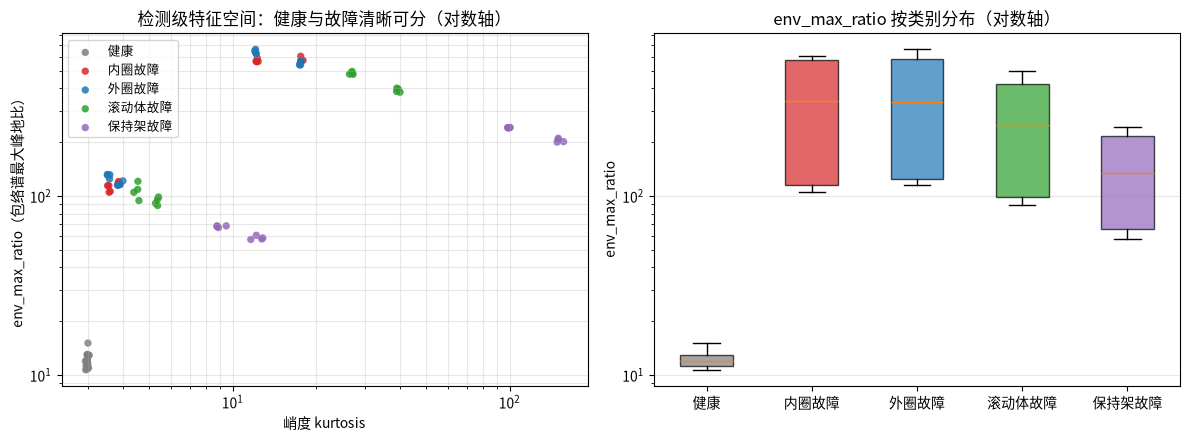

In [4]:
df_feat = pd.DataFrame(dataset.X, columns=dataset.feature_names)
df_feat["class"] = [dataset.classes[i] for i in dataset.y]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax = axes[0]
for c in dataset.classes:
    sub = df_feat[df_feat["class"] == c]
    ax.scatter(sub["kurtosis"], sub["env_max_ratio"], s=28, alpha=0.85,
               color=CLASS_COLORS[c], label=FAULT_LABELS[c], edgecolors="none")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("峭度 kurtosis")
ax.set_ylabel("env_max_ratio（包络谱最大峰地比）")
ax.set_title("检测级特征空间：健康与故障清晰可分（对数轴）")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which="both")

ax = axes[1]
data = [df_feat.loc[df_feat["class"] == c, "env_max_ratio"] for c in dataset.classes]
bp = ax.boxplot(data, tick_labels=[FAULT_LABELS[c] for c in dataset.classes],
                patch_artist=True)
for patch, c in zip(bp["boxes"], dataset.classes):
    patch.set_facecolor(CLASS_COLORS[c])
    patch.set_alpha(0.7)
ax.set_yscale("log")
ax.set_ylabel("env_max_ratio")
ax.set_title("env_max_ratio 按类别分布（对数轴）")
ax.grid(alpha=0.3, axis="y")

fig.tight_layout()
plt.show()


## 3 两级训练

`train_two_stage` 一行完成全部训练：

1. **分层划分**：按 5 类标签分层随机留出 30% 测试集（训练 56 / 测试 24）；
2. **检测级**：只用训练集中**健康样本**的 4 维检测特征拟合
   `StandardScaler + EllipticEnvelope`（稳健协方差 / 马氏距离，
   `contamination=0.01`）——健康样本在特征空间中聚成紧凑的"正常域"，
   马氏距离超出阈值的样本判为异常；
3. **分类级**：只用训练集中的**故障样本**，对 SVM(RBF) / 随机森林 / kNN
   三个候选做 5 折交叉验证，择优后用全部故障训练样本拟合。

> **教训：为什么默认不用 IsolationForest？**
> IsolationForest 曾是检测级默认（`stage1="isolation_forest"` 仍可手动选择），
> 但网格扫描实测它在一半配置下**检出率塌缩为 0**——全部故障被判正常。原因有二：
> 其分裂界由训练数据的 min/max 决定、不随极端程度外推，对远超训练范围的极端
> 故障点不敏感；且判定阈值按训练分数的 `contamination` 分位数标定，随健康
> 样本数漂移。EllipticEnvelope 基于马氏距离、天然距离感知，同批实验在全部
> 配置下检出率 1.0，因此成为默认。教训：**无监督异常检测器必须在多种工况
> 网格下回归测试，单一配置上的"好用"不可信**。

打印三个候选分类器的 5 折 CV 成绩：


In [5]:
result = train_two_stage(dataset, test_size=0.3, seed=SEED)  # stage1 缺省即 EllipticEnvelope

stage1_name = type(result.model.stage1.named_steps["clf"]).__name__
cv = pd.DataFrame({"5 折 CV 平均准确率": result.cv_scores})
cv.index.name = "候选分类器"
cv["择优"] = ["← 最优" if n == result.best_stage2 else "" for n in cv.index]
print(f"检测级: {stage1_name}（仅健康样本）   分类级择优结果: {result.best_stage2}")
cv.round(4)


检测级: EllipticEnvelope（仅健康样本）   分类级择优结果: random_forest


,5 折 CV 平均准确率,择优
候选分类器,,
svm_rbf,0.9333,
random_forest,1.0000,← 最优
knn,0.8889,


## 4 测试集评估

`evaluate` 输出两组指标：

- **级联 5 类指标**：检测级 + 分类级串联后的整体准确率与各类
  precision / recall / f1；
- **检测级指标**：把预测折叠为 健康/异常 二分类后的故障**检出率**
  （detection rate）与健康**误报率**（false alarm rate）。


In [6]:
metrics = evaluate(result)
det = metrics["detection"]
print(f"级联 5 类准确率: {metrics['accuracy']:.4f}（测试集 {len(result.y_test)} 个样本）")
print(f"检测级: 故障检出率 {det['detection_rate']:.4f}，健康误报率 {det['false_alarm_rate']:.4f}")

report_dict = {k: v for k, v in metrics["classification_report"].items() if k != "accuracy"}
report = pd.DataFrame(report_dict).T.round(3)
report


级联 5 类准确率: 1.0000（测试集 24 个样本）
检测级: 故障检出率 1.0000，健康误报率 0.0000


,precision,recall,f1-score,support
healthy,1.0,1.0,1.0,5.0
inner,1.0,1.0,1.0,4.0
outer,1.0,1.0,1.0,5.0
ball,1.0,1.0,1.0,5.0
cage,1.0,1.0,1.0,5.0
macro avg,1.0,1.0,1.0,24.0
weighted avg,1.0,1.0,1.0,24.0


24 个测试样本**全部判对**：检测级健康零误报、故障零漏检，分类级对四种故障
部位的判断也全部正确，混淆矩阵为完美对角阵。需要强调：24 个样本的满分
不能外推为生产水平——小网格只覆盖 2 种转速、2 种 SNR，这正是生产环境
要用默认 360 网格训练的原因。混淆矩阵（行=真实，列=预测）：


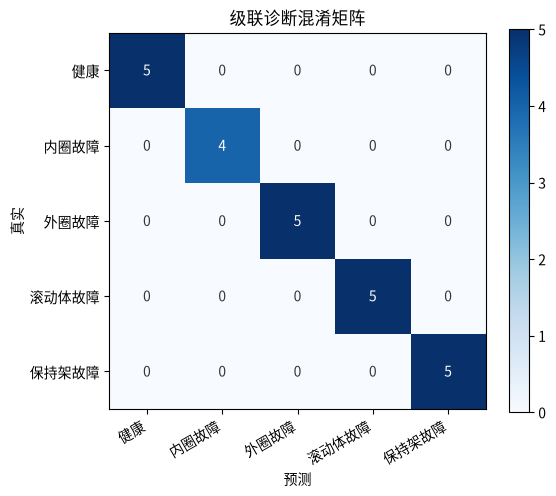

In [7]:
cm = np.array(metrics["confusion_matrix"])
fig, _ = plot_confusion_matrix(cm, result.classes)
plt.show()


分类级择优结果为 **random_forest**，可直接读取特征重要性（若择优结果为
SVM / kNN 则没有 `feature_importances_`，此时 `feature_importances()` 返回
空表，只能退而比较上方 CV 成绩）：


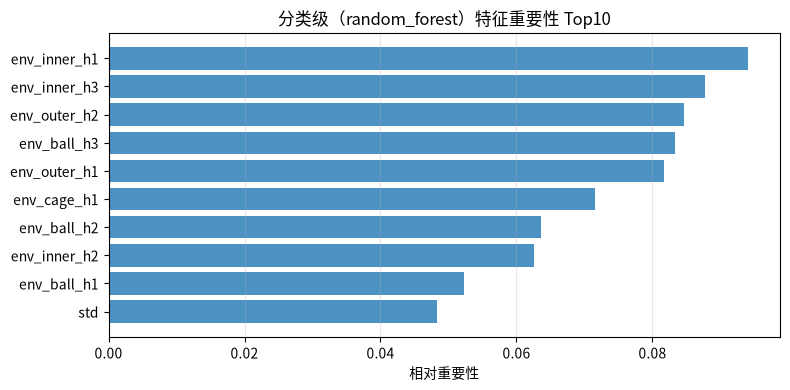

In [8]:
imp = feature_importances(result, top=10)
if imp:
    names, vals = zip(*imp)
    y_pos = np.arange(len(imp))
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(y_pos, vals, color="tab:blue", alpha=0.8)
    ax.set_yticks(y_pos, names)
    ax.invert_yaxis()
    ax.set_xlabel("相对重要性")
    ax.set_title(f"分类级（{result.best_stage2}）特征重要性 Top10")
    ax.grid(alpha=0.3, axis="x")
    fig.tight_layout()
    plt.show()
else:
    print(f"最优分类器为 {result.best_stage2}，无特征重要性；候选对比见上方 CV 表")


Top10 中 9 席被包络谱峰地比特征（`env_*`）占据，唯一进入的非包络特征是 `std`——
与第 04 节"包络分析是故障定位的核心手段"的结论互相印证。


## 5 推理演示：对一段全新信号做端到端预测

`predict_one(x, rpm)` 内部自动完成 特征提取 → 检测 → 分类，返回：

- `verdict`：最终结论（5 类之一）；
- `anomaly`：检测级判定（True = 异常）；
- `fault_proba`：各故障类型的分类概率（判健康时为 None）；
- `features`：26 维特征字典。

用一段**训练网格之外**的信号测试：新种子 777、时长 2 s、-6 dB 低信噪比的
内圈故障，并附一段健康信号（seed=778）作对照：


In [9]:
model = result.model

x_inner = BearingSimulator(fs=FS, duration=2.0, rpm=1797, seed=777).signal("inner", snr_db=-6.0)
res = model.predict_one(x_inner, 1797)
print("输入: 内圈故障仿真信号（seed=777, 1797 rpm, -6 dB, 2 s）")
print(f"检测级: {'异常' if res['anomaly'] else '正常'}")
print(f"verdict: {res['verdict']}（{FAULT_LABELS[res['verdict']]}）")
proba = pd.Series(res["fault_proba"]).sort_values(ascending=False)
proba.index = [FAULT_LABELS[k] for k in proba.index]
print("fault_proba:")
print(proba.round(3).to_string())
assert res["verdict"] == "inner", "推理结论与真实故障类型不符"

x_healthy = BearingSimulator(fs=FS, duration=2.0, rpm=1797, seed=778).signal("healthy")
res_h = model.predict_one(x_healthy, 1797)
print(f"\n健康对照: verdict={res_h['verdict']}，anomaly={res_h['anomaly']}，"
      f"fault_proba={res_h['fault_proba']}")
assert res_h["verdict"] == "healthy", "健康样本被误判"
print("\n推理演示通过 ✔")


输入: 内圈故障仿真信号（seed=777, 1797 rpm, -6 dB, 2 s）
检测级: 异常
verdict: inner（内圈故障）
fault_proba:
内圈故障     0.92
滚动体故障    0.05
外圈故障     0.02
保持架故障    0.01

健康对照: verdict=healthy，anomaly=False，fault_proba=None

推理演示通过 ✔


## 6 小结

- **两级架构**：检测级只用健康样本（EllipticEnvelope 稳健马氏距离，4 维冲击性
  特征），异常样本才进入分类级（SVM / RF / kNN 交叉验证择优）。故障样本稀缺、
  类型不全甚至未知时仍可先上线异常检测——这对工业现场至关重要；
- 本节的 80 样本小网格上级联准确率 1.0、检测级零误报零漏检（24 样本测试集）；
  特征重要性显示包络谱峰地比（`env_*`）是分类级的核心特征组，与第 04 节理论一致；
- 生产环境用法（默认 360 样本网格，CLI 一键完成）：

```bash
bearing-fault ml-dataset --out data/ml_dataset.npz                    # 生成数据集
bearing-fault ml-train --dataset data/ml_dataset.npz --out models     # 训练 + 评估 + 保存模型
bearing-fault ml-predict --model models/two_stage.joblib --fault inner --snr -6   # 对信号做两级推理
```

- 深入阅读：[docs/08_machine_learning.md](../docs/08_machine_learning.md)——
  两级架构的设计权衡、检测级算法对比与完整指标解读。

至此 7 个 notebook 覆盖了 信号仿真 → 时域特征 → 包络分析 → 阶次/时频分析 →
传统诊断流程 → 机器学习两级识别 的完整链条，对应 docs/ 01–08 章。
